In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# SPEECHES

In [ ]:
df_updated = pd.read_csv('BSP_Speeches_Updated.csv')

In [ ]:
# Check if 'Year' exists, otherwise create it from 'Date' column
if 'Year' not in df_updated.columns:
    df_updated['Year'] = pd.to_datetime(df_updated['Date']).dt.year

In [ ]:
df_updated

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,Year
0,Going Digital: Changing the Digital Finance Na...,2025-03-20,BSP Manila,4th Digital Financial Inclusion Awards,"BSP Governor Eli. M. Remolona, Jr.","Introduction Good afternoon, everyone. Good af...",394,https://www.bsp.gov.ph/SitePages/MediaAndResea...,2025
1,Getting Out of the Grey List--And Staying Out,2025-03-11,"Edsa Shangri-La, Mandaluyong City",Tuesday Club Meeting,"BSP Governor Eli M. Remolona, Jr.","Good morning, Tuesday Club! Thank you once aga...",1257,https://www.bsp.gov.ph/SitePages/MediaAndResea...,2025
2,Speech for the National AML/CTF/CPF Coordinati...,2025-03-05,BSP Manila,NaN,"BSP Governor Eli. M. Remolona, Jr.","Good morning, everyone! Magandang umaga po. Fi...",284,https://www.bsp.gov.ph/SitePages/MediaAndResea...,2025
3,Keynote Message for the Annual Reception for t...,2025-01-10,BSP Manila,2025 Annual Reception for the Banking Community,"BSP Governor Eli M. Remolona, Jr.","Good evening, everyone. Former central bank go...",336,https://www.bsp.gov.ph/SitePages/MediaAndResea...,2025
4,Welcome Message for the 3rd Digital Financial ...,2024-12-13,BSP Manila,3rd Digital Financial Inclusion Awards,"BSP Governor Eli M. Remolona, Jr.","Introduction Citi Philippines CEO Paul Favila,...",402,https://www.bsp.gov.ph/SitePages/MediaAndResea...,2024
...,...,...,...,...,...,...,...,...,...
1043,THE PHILIPPINES: CAPITALIZING ON SUSTAINED FIN...,1998-11-11,"Shangri-La Manila Hotel, Makati City",Euromoney Conference,Governor Gabriel Singson,INTRODUCTION It is quite clear that Asia is st...,1657,https://www.bsp.gov.ph/SitePages/MediaAndResea...,1998
1044,BSP ON ITS 5TH YEAR ANNIVERSARY: MANAGING THE ...,1998-07-03,BSP Cafetorium,NaN,Governor Gabriel Singson,Our 5th anniversary celebrations today follow ...,1047,https://www.bsp.gov.ph/SitePages/MediaAndResea...,1998
1045,ON WITH THE ECONOMIC RECOVERY...CAREFULLY,1998-05-28,"Grand Ballroom, Hotel Intercontinental, Makati...",5th Monthly Business Meeting of the Chamber of...,Governor Gabriel Singson,I feel encouraged by the theme you have adopte...,1601,https://www.bsp.gov.ph/SitePages/MediaAndResea...,1998
1046,An Update on Recent Economic Developments,1998-05-22,"Peninsula Hotel, Makati City",Asia Society breakfast meeting,Governor Gabriel Singson,"For many months now, developments in Asia have...",1349,https://www.bsp.gov.ph/SitePages/MediaAndResea...,1998


## Summary Statistics for Length of Speeches

In [ ]:
# Summary statistics for 'Len' (Length of Speeches)
len_summary = df_updated['Len'].describe()
print(len_summary)

count    1048.000000
mean     1322.805344
std       721.578925
min         0.000000
25%       726.750000
50%      1255.500000
75%      1816.000000
max      4643.000000
Name: Len, dtype: float64


## Distribution Analysis

### Total Number of Speeches

                                   Speaker  total_speeches
62            Governor Rafael Buenaventura             204
11         BSP Governor Benjamin E. Diokno             188
49        Governor Amando M. Tetangco, Jr.             165
19          BSP Governor Felipe M. Medalla              83
8     BSP Governor Amando M. Tetangco, Jr.              61
15  BSP Governor Benjamin E. Diokno, Ph.D.              59
43       Governor  Amando M. Tetangco, Jr.              56
21   BSP Governor Nestor A. Espenilla, Jr.              50
16       BSP Governor Eli M. Remolona, Jr.              25
52             Governor Benjamin E. Diokno              18


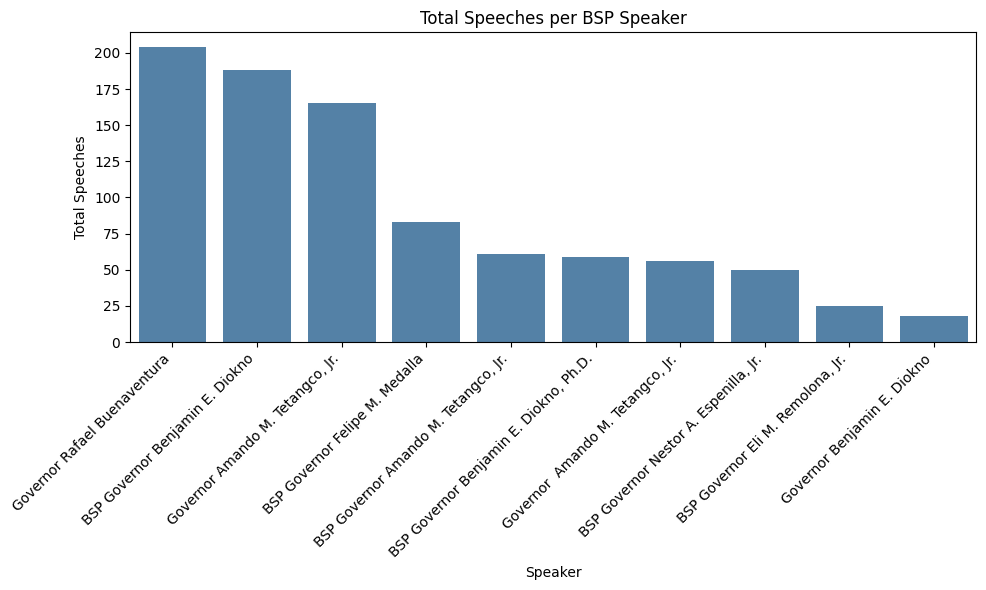

In [ ]:
# Count total speeches per speaker
agg_speaker = df_updated.groupby('Speaker').size().reset_index(name='total_speeches')

# Sort by total speeches in decreasing order
agg_speaker = agg_speaker.sort_values(by='total_speeches', ascending=False)

# Display top 10 speakers
print(agg_speaker.head(10))

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=agg_speaker.head(10), x='Speaker', y='total_speeches', color='steelblue')

# Adding labels and title
plt.title('Total Speeches per BSP Speaker')
plt.xlabel('Speaker')
plt.ylabel('Total Speeches')

# Rotate the x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

### Number of Speeches per Year and Governor

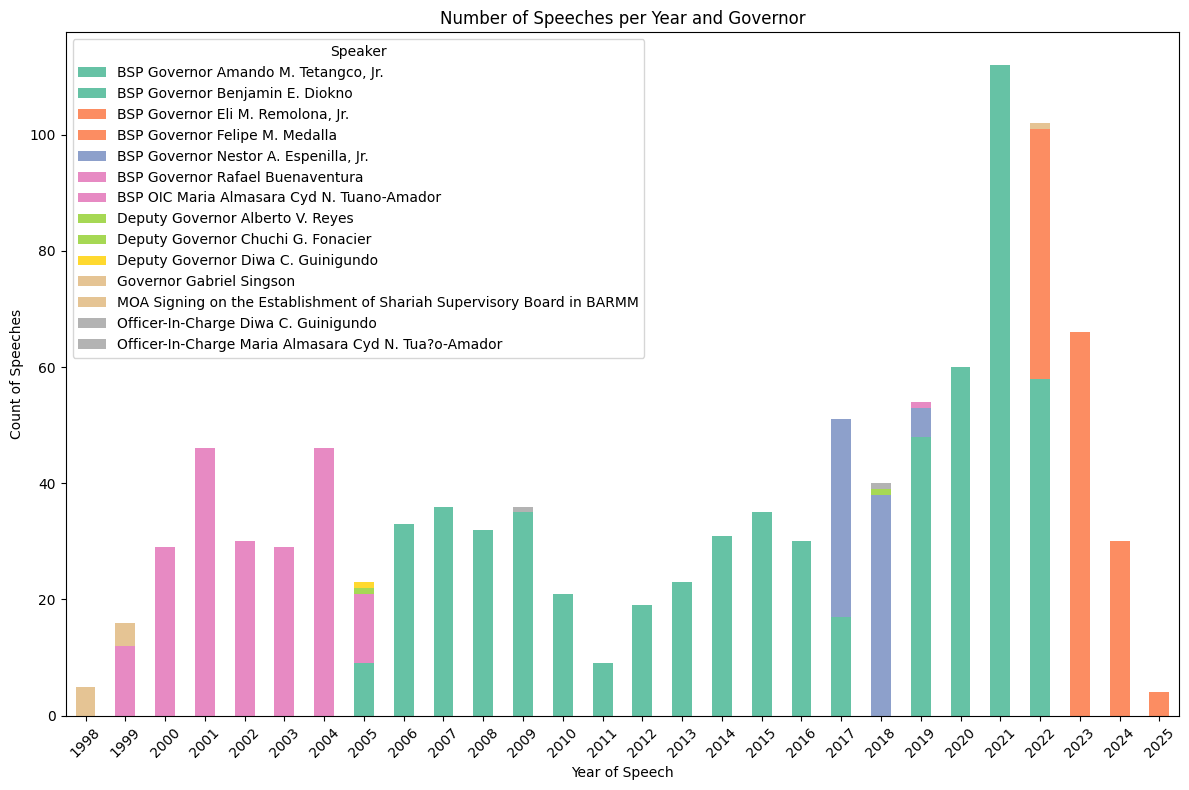

In [ ]:
# Function to standardize speaker names using regex
def standardize_name(name):
    # Standardize "Benjamin" to "BSP Governor Benjamin E. Diokno"
    if re.search(r'Benjamin', name, re.IGNORECASE):
        return 'BSP Governor Benjamin E. Diokno'
    # Standardize "Nestor" to "BSP Governor Nestor A. Espenilla, Jr."
    elif re.search(r'Nestor', name, re.IGNORECASE):
        return 'BSP Governor Nestor A. Espenilla, Jr.'
    # Standardize "Amando" to "BSP Governor Amando M. Tetangco, Jr."
    elif re.search(r'Amando', name, re.IGNORECASE):
        return 'BSP Governor Amando M. Tetangco, Jr.'
    # Standardize "Rafael" to "BSP Governor Rafael Buenaventura"
    elif re.search(r'Rafael', name, re.IGNORECASE):
        return 'BSP Governor Rafael Buenaventura'
    # Standardize "Felipe" to "BSP Governor Felipe M. Medalla"
    elif re.search(r'Felipe', name, re.IGNORECASE):
        return 'BSP Governor Felipe M. Medalla'
    elif re.search(r'Eli', name, re.IGNORECASE):
        return 'BSP Governor Eli M. Remolona, Jr.'
    # Add other standardizations as necessary
    return name

# Apply the standardization function to the 'Speaker' column
df_updated['Speaker'] = df_updated['Speaker'].apply(standardize_name)

# Now proceed with the aggregation
agg_counts = df_updated.groupby(['Speaker', 'Year']).size().reset_index(name='Amount')

# Create a pivot table to plot Number of Speeches per Governor per Year
pivot_counts = agg_counts.pivot_table(index='Year', columns='Speaker', values='Amount', aggfunc='sum', fill_value=0)

# Plotting the stacked bar chart for Number of Speeches per Year and Governor
pivot_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Set2')

# Adding labels and title
plt.title('Number of Speeches per Year and Governor')
plt.xlabel('Year of Speech')
plt.ylabel('Count of Speeches')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Apply the standardization function to the 'Speaker' column
df_updated['Standardized Speaker'] = df_updated['Speaker'].apply(standardize_name)

# Get the unique governors from the 'Standardized Speaker' column
df_updated['Standardized Speaker'].unique()

array(['BSP Governor Eli M. Remolona, Jr.',
       'BSP Governor Felipe M. Medalla',
       'BSP Governor Benjamin E. Diokno',
       'MOA Signing on the Establishment of Shariah Supervisory Board in BARMM',
       'BSP Governor Amando M. Tetangco, Jr.',
       'BSP OIC Maria Almasara Cyd N. Tuano-Amador',
       'BSP Governor Nestor A. Espenilla, Jr.',
       'Deputy Governor Chuchi G. Fonacier',
       'Officer-In-Charge Maria Almasara Cyd N. Tua?o-Amador',
       'Officer-In-Charge Diwa C. Guinigundo',
       'Deputy Governor Diwa C. Guinigundo',
       'BSP Governor Rafael Buenaventura',
       'Deputy Governor Alberto V. Reyes', 'Governor Gabriel Singson'],
      dtype=object)

### Length of Speeches per Year and Governor

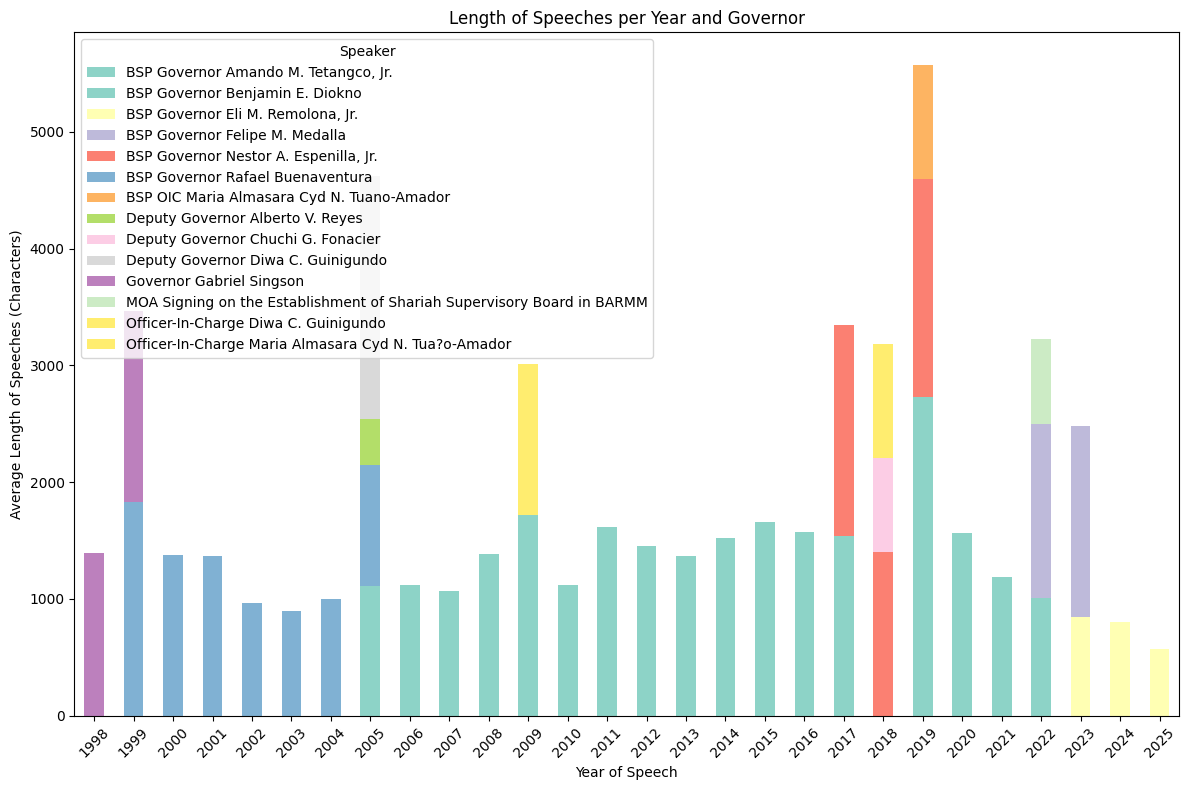

In [ ]:
agg_len = df_updated.groupby(['Speaker', 'Year'])['Len'].mean().reset_index(name='Avg_Length')
pivot_len = agg_len.pivot_table(index='Year', columns='Speaker', values='Avg_Length', aggfunc='mean', fill_value=0)

# Plotting the stacked bar chart for Length of Speeches per Year and Governor
pivot_len.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Set3')

# Adding labels and title
plt.title('Length of Speeches per Year and Governor')
plt.xlabel('Year of Speech')
plt.ylabel('Average Length of Speeches (Characters)')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

### Length of Speeches vs Number of Speeches

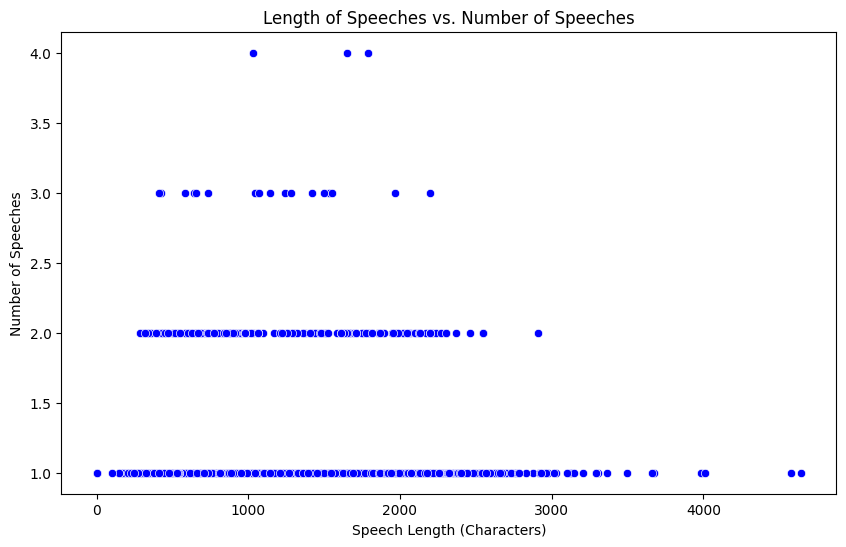

In [ ]:
length_counts = df_updated['Len'].value_counts().reset_index()

# Rename the columns for clarity
length_counts.columns = ['Speech Length', 'Number of Speeches']

# Plotting Length of Speeches vs. Number of Speeches as a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=length_counts, x='Speech Length', y='Number of Speeches', color='b')

# Adding labels and title
plt.title('Length of Speeches vs. Number of Speeches')
plt.xlabel('Speech Length (Characters)')
plt.ylabel('Number of Speeches')

# Display the plot
plt.show()

## Heatmap for Number of Speeches per Month per Year

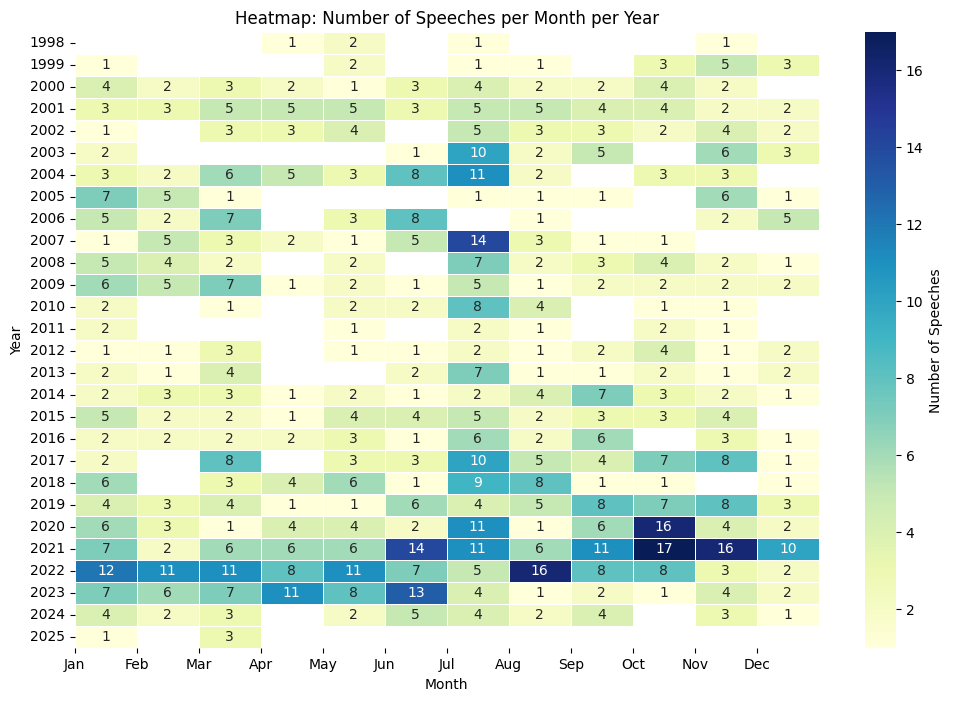

In [ ]:
df_updated['Month'] = pd.to_datetime(df_updated['Date']).dt.month
pivot_speeches = df_updated.pivot_table(index='Year', columns='Month', values='Title', aggfunc='count')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_speeches, annot=True, cmap='YlGnBu', fmt='g', linewidths=0.5, cbar_kws={'label': 'Number of Speeches'})
plt.title('Heatmap: Number of Speeches per Month per Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

## Heatmap for Length of Speeches per Month per Year

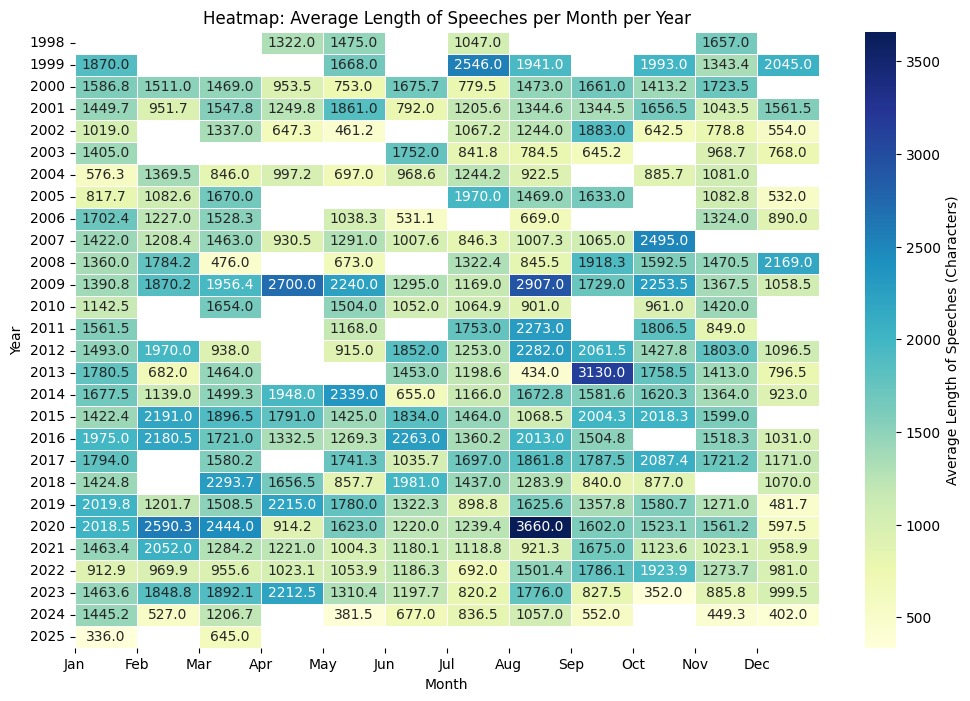

In [ ]:
pivot_len_month = df_updated.pivot_table(index='Year', columns='Month', values='Len', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_len_month, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Average Length of Speeches (Characters)'})
plt.title('Heatmap: Average Length of Speeches per Month per Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# INTEREST RATE

In [ ]:
# Load the dataset
df_interest_rate = pd.read_csv('interest_rate_clean.csv')

# Check the first few rows of the dataset to understand its structure
df_interest_rate.head()

,DATE,CPI,Interbank Call Loan Rate,Real GDP
0,1995-01-31,34.336496,9.119048,43.018447
1,1995-02-28,34.598607,13.328125,41.120262
2,1995-03-31,34.664135,19.073370,37.400557
3,1995-04-30,34.795190,20.375000,35.757695
4,1995-05-31,34.991773,11.413690,40.782735


In [ ]:
# Drop 'Date' and 'Past Rate Change Class' columns from numerical features
numerical_cols = df_interest_rate.select_dtypes(include=['number']).columns
numerical_cols = [col for col in numerical_cols if col not in ['Date', 'Past Rate Change Class', 'CPI_norm','RealGDP_norm', 'ICLR_norm', 'CPI_z', 'RealGDP_z', 'ICLR_z', 'Year']]

# Summary statistics for all numerical columns (without count)
summary_stats = df_interest_rate[numerical_cols].describe().drop('count')
print(summary_stats)

             CPI  Interbank Call Loan Rate    Real GDP
mean   76.732970                  6.424319   86.254428
std    25.592648                  4.094872   35.861264
min    34.336496                  1.535187   35.757695
25%    54.387962                  3.235888   53.243381
50%    77.453700                  5.829545   76.449837
75%    94.671782                  7.971828  118.250884
max   127.700000                 34.114143  163.413452


In [ ]:
# Convert DATE column to datetime
df_interest_rate['DATE'] = pd.to_datetime(df_interest_rate['DATE'])

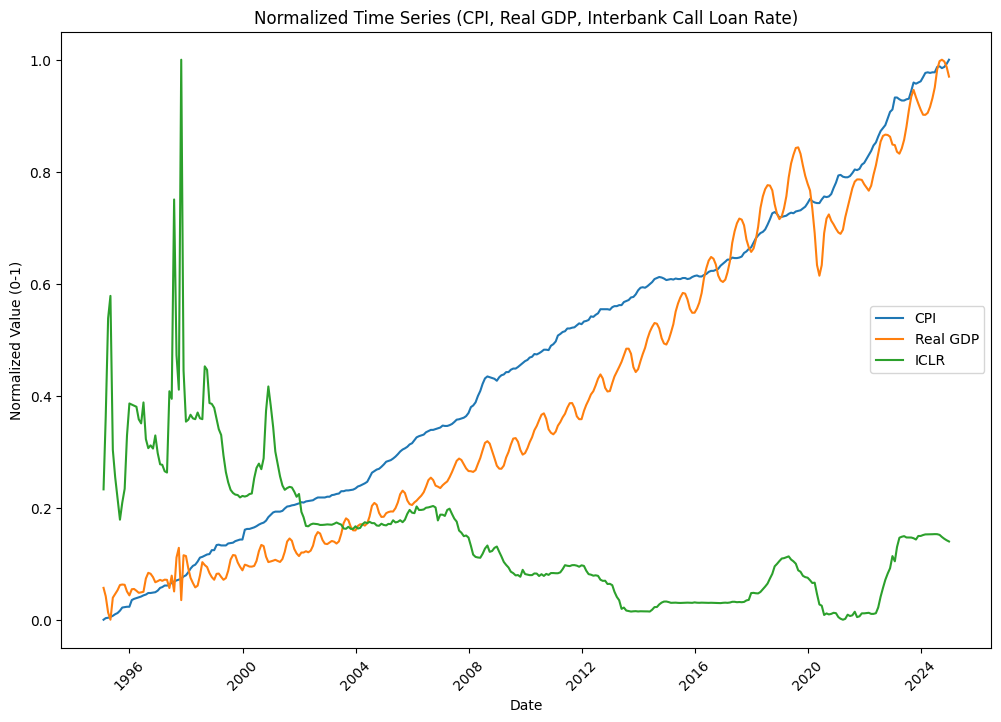

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_interest_rate[['CPI_norm', 'RealGDP_norm', 'ICLR_norm']] = scaler.fit_transform(
    df_interest_rate[['CPI', 'Real GDP', 'Interbank Call Loan Rate']]
)

# Plot normalized values together
plt.figure(figsize=(12, 8))
plt.plot(df_interest_rate['DATE'], df_interest_rate['CPI_norm'], label='CPI')
plt.plot(df_interest_rate['DATE'], df_interest_rate['RealGDP_norm'], label='Real GDP')
plt.plot(df_interest_rate['DATE'], df_interest_rate['ICLR_norm'], label='ICLR')

plt.title('Normalized Time Series (CPI, Real GDP, Interbank Call Loan Rate)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (0-1)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

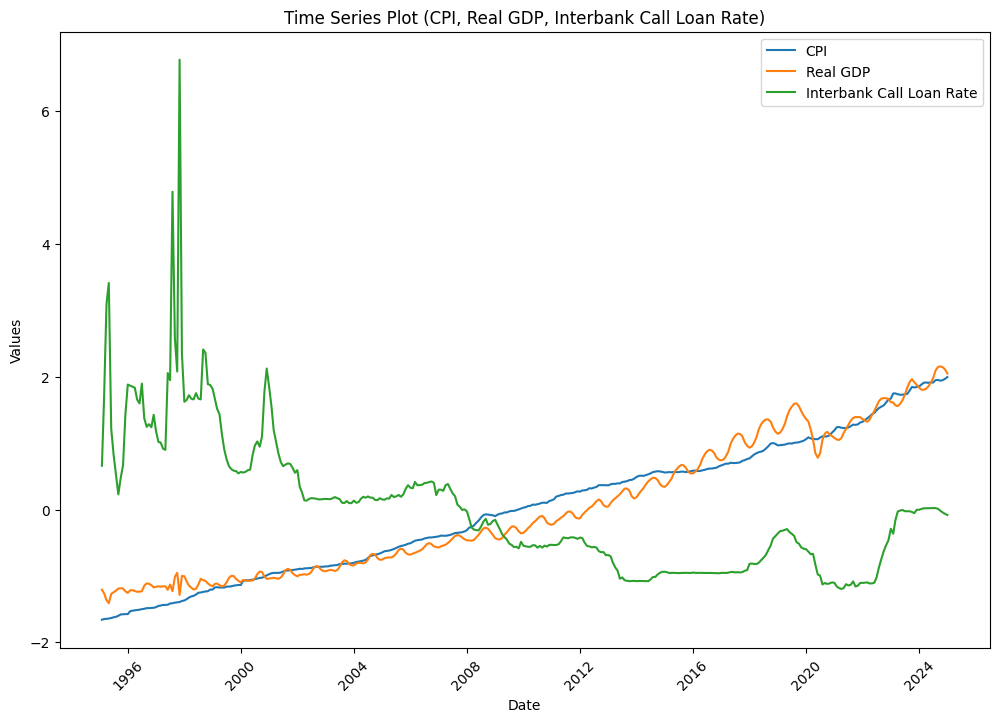

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_interest_rate[['CPI_z', 'RealGDP_z', 'ICLR_z']] = scaler.fit_transform(
    df_interest_rate[['CPI', 'Real GDP', 'Interbank Call Loan Rate']]
)

# Plot standardized values together
plt.figure(figsize=(12, 8))
plt.plot(df_interest_rate['DATE'], df_interest_rate['CPI_z'], label='CPI')
plt.plot(df_interest_rate['DATE'], df_interest_rate['RealGDP_z'], label='Real GDP')
plt.plot(df_interest_rate['DATE'], df_interest_rate['ICLR_z'], label='Interbank Call Loan Rate')

plt.title('Time Series Plot (CPI, Real GDP, Interbank Call Loan Rate)')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.show()

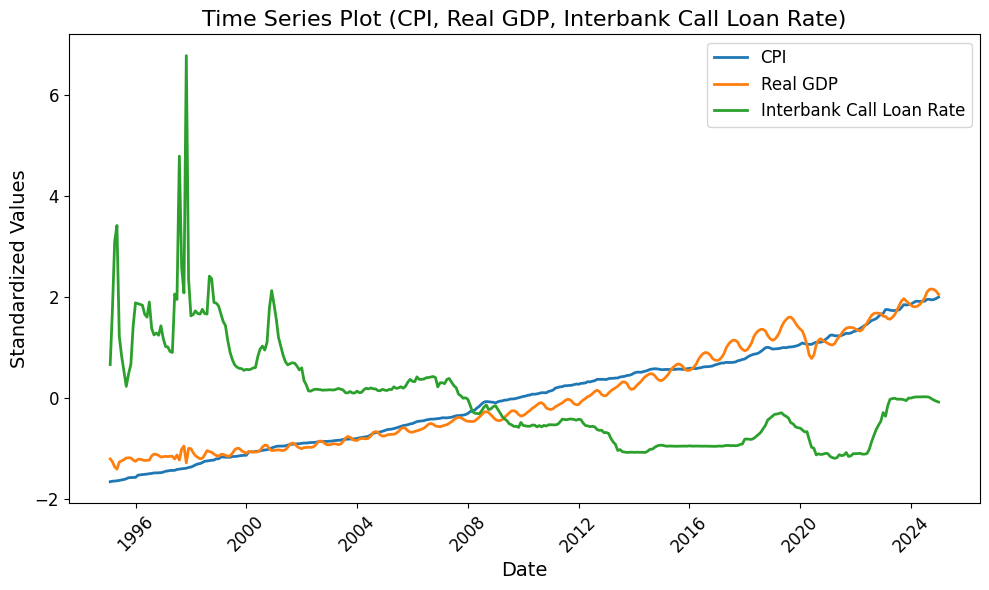

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
df_interest_rate[['CPI_z', 'RealGDP_z', 'ICLR_z']] = scaler.fit_transform(
    df_interest_rate[['CPI', 'Real GDP', 'Interbank Call Loan Rate']]
)

# Convert date to datetime if needed
df_interest_rate['DATE'] = pd.to_datetime(df_interest_rate['DATE'])

# Plot standardized values together
plt.figure(figsize=(10, 6))  # smaller figure
plt.plot(df_interest_rate['DATE'], df_interest_rate['CPI_z'], label='CPI', linewidth=2)
plt.plot(df_interest_rate['DATE'], df_interest_rate['RealGDP_z'], label='Real GDP', linewidth=2)
plt.plot(df_interest_rate['DATE'], df_interest_rate['ICLR_z'], label='Interbank Call Loan Rate', linewidth=2)

# Titles and labels with larger font sizes
plt.title('Time Series Plot (CPI, Real GDP, Interbank Call Loan Rate)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Standardized Values', fontsize=14)
plt.legend(fontsize=12)

# Format x-axis: show only every 4 years
plt.gca().xaxis.set_major_locator(mdates.YearLocator(4))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

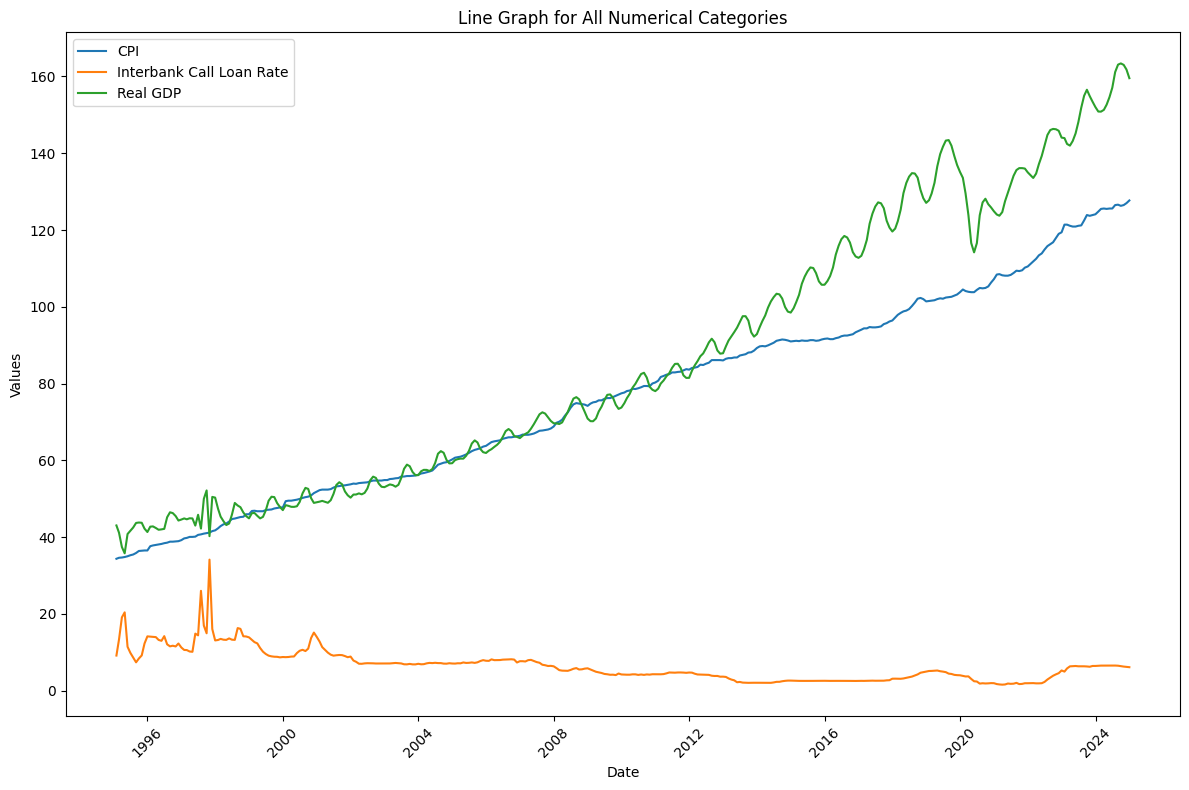

In [ ]:
# Plot a line graph for each numerical column
plt.figure(figsize=(12, 8))
for col in numerical_cols:
    plt.plot(df_interest_rate['DATE'], df_interest_rate[col], label=col)

plt.title('Line Graph for All Numerical Categories')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

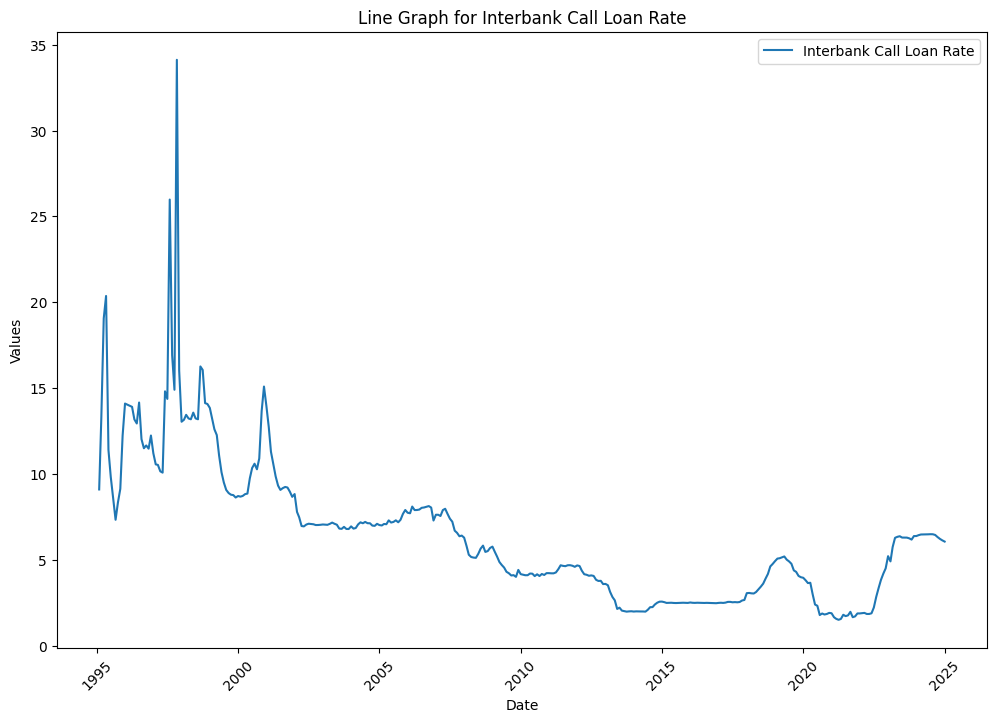

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 8))
plt.plot(df_interest_rate['DATE'], df_interest_rate['Interbank Call Loan Rate'], label='Interbank Call Loan Rate')

plt.title('Line Graph for Interbank Call Loan Rate')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()

# Show every year (you can adjust to 5 years for readability)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.show()

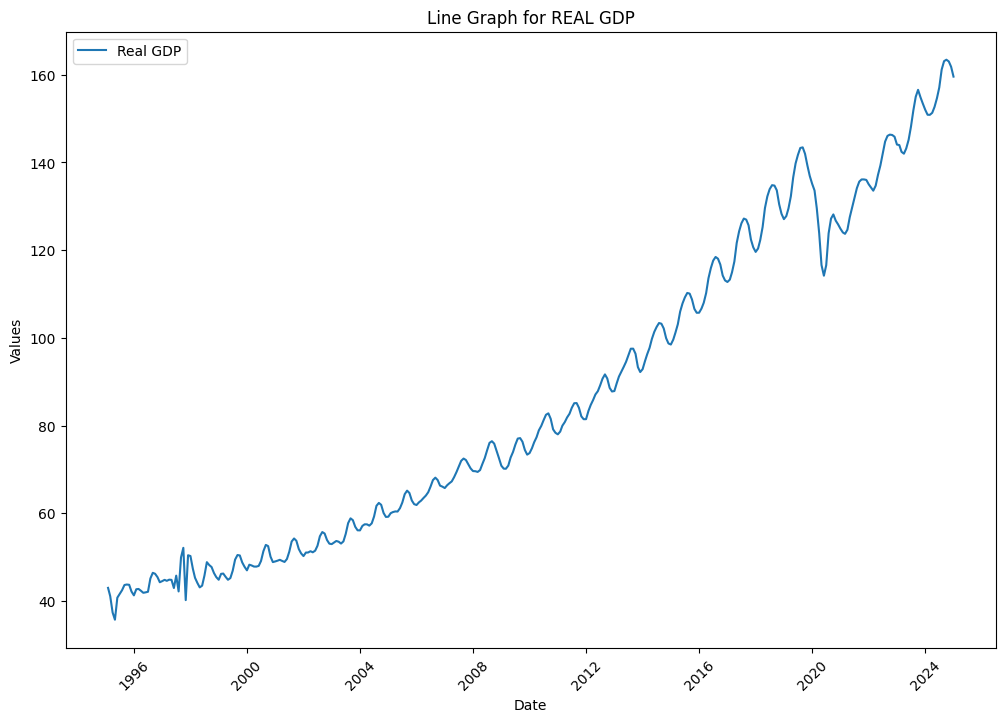

In [ ]:
# Plot a line graph for each numerical column
plt.figure(figsize=(12, 8))
plt.plot(df_interest_rate['DATE'], df_interest_rate['Real GDP'], label='Real GDP')

plt.title('Line Graph for REAL GDP')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.show()

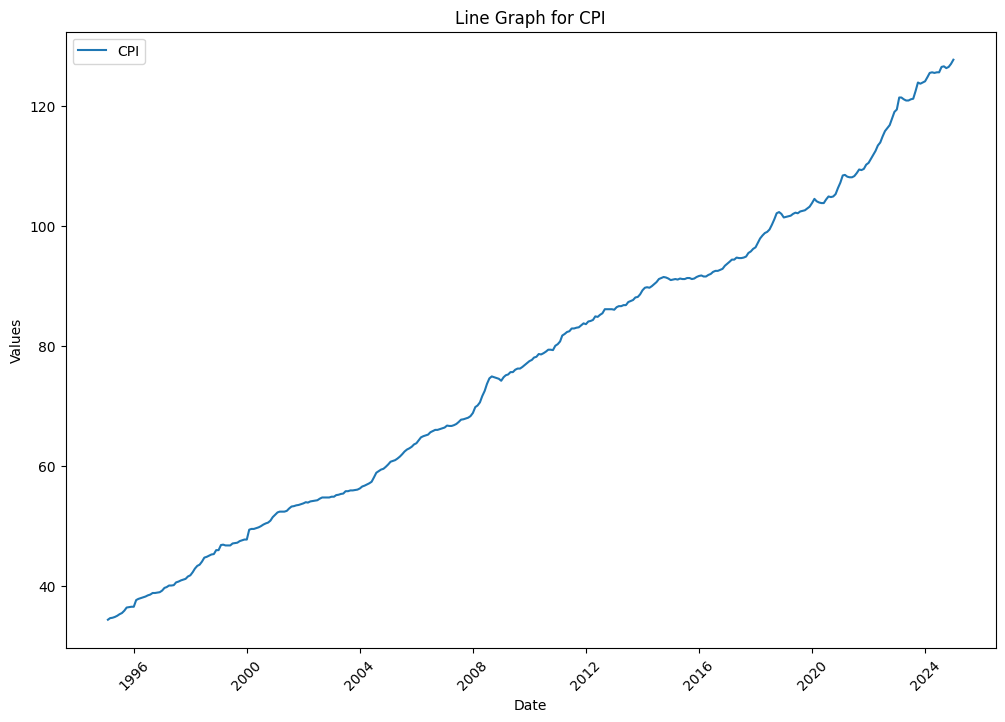

In [ ]:
# Plot a line graph for each numerical column
plt.figure(figsize=(12, 8))
plt.plot(df_interest_rate['DATE'], df_interest_rate['CPI'], label='CPI')

plt.title('Line Graph for CPI')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.show()

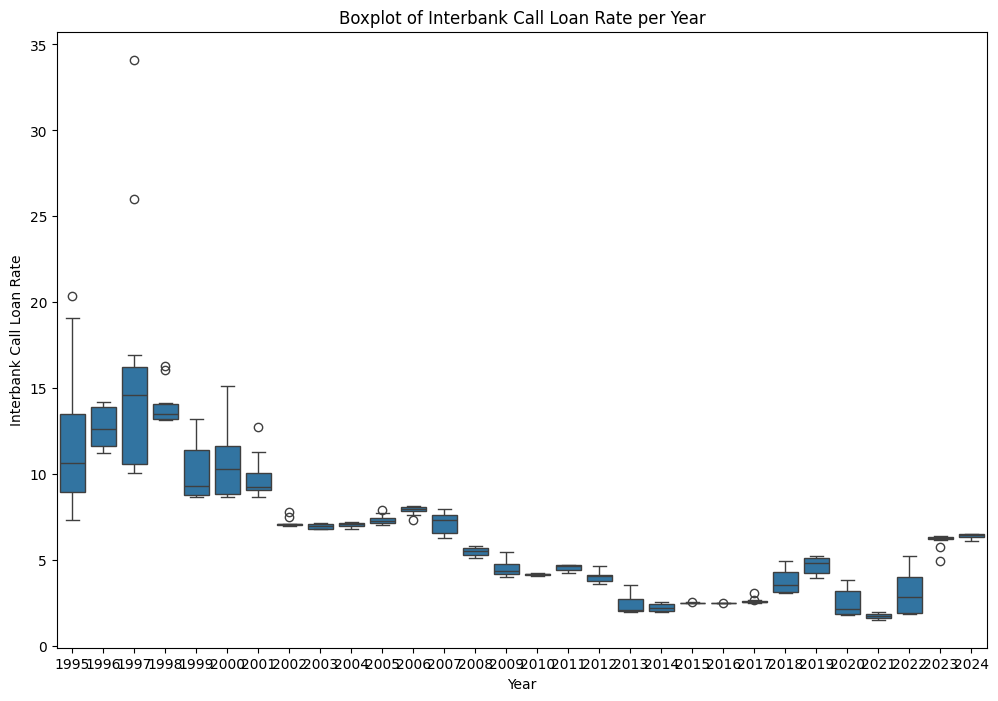

In [ ]:
# Extract the year from the 'Date' column
df_interest_rate['Year'] = pd.to_datetime(df_interest_rate['DATE'], format='%Y-%m-%d').dt.year

# Plot boxplots per Year for each numerical column
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_interest_rate, x='Year', y="Interbank Call Loan Rate")
plt.title(f'Boxplot of Interbank Call Loan Rate per Year')

plt.show()

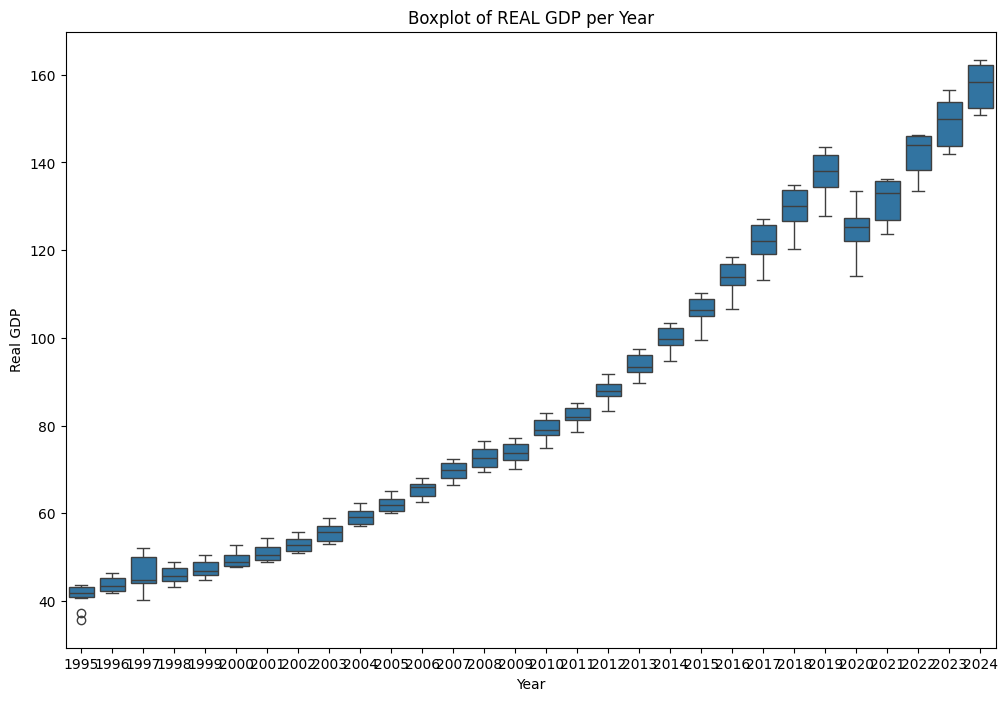

In [ ]:
# Extract the year from the 'Date' column
df_interest_rate['Year'] = pd.to_datetime(df_interest_rate['DATE'], format='%Y-%m-%d').dt.year

# Plot boxplots per Year for each numerical column
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_interest_rate, x='Year', y="Real GDP")
plt.title(f'Boxplot of REAL GDP per Year')

plt.show()

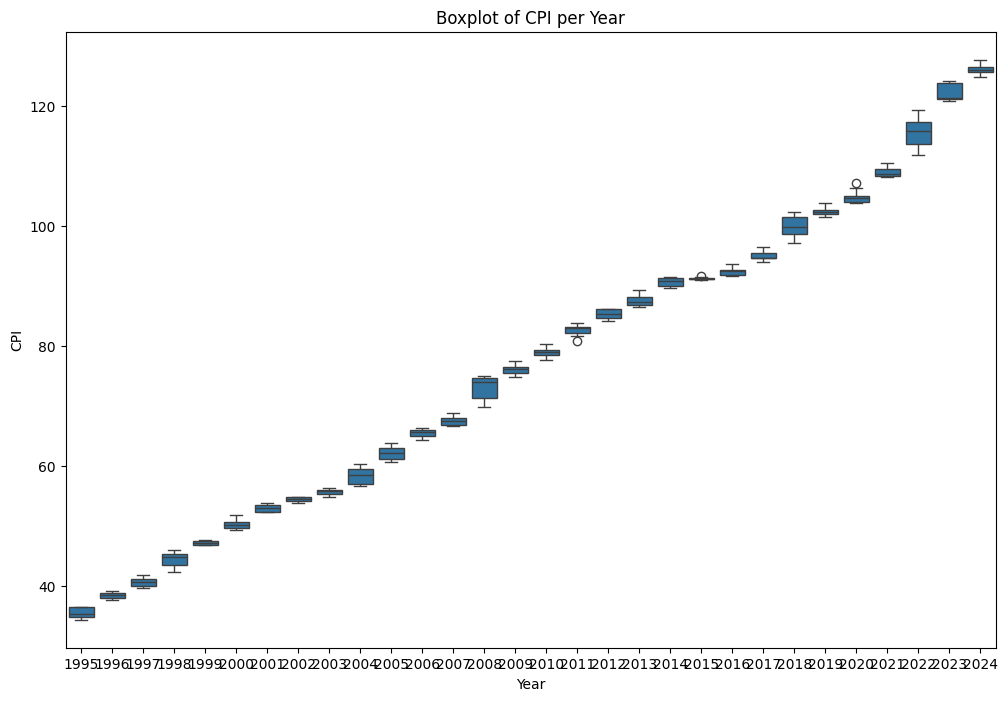

In [ ]:
# Extract the year from the 'Date' column
df_interest_rate['Year'] = pd.to_datetime(df_interest_rate['DATE'], format='%Y-%m-%d').dt.year

# Plot boxplots per Year for each numerical column
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_interest_rate, x='Year', y="CPI")
plt.title(f'Boxplot of CPI per Year')

plt.show()

                          Interbank Call Loan Rate  Real GDP
Interbank Call Loan Rate                  1.000000 -0.655469
Real GDP                                 -0.655469  1.000000


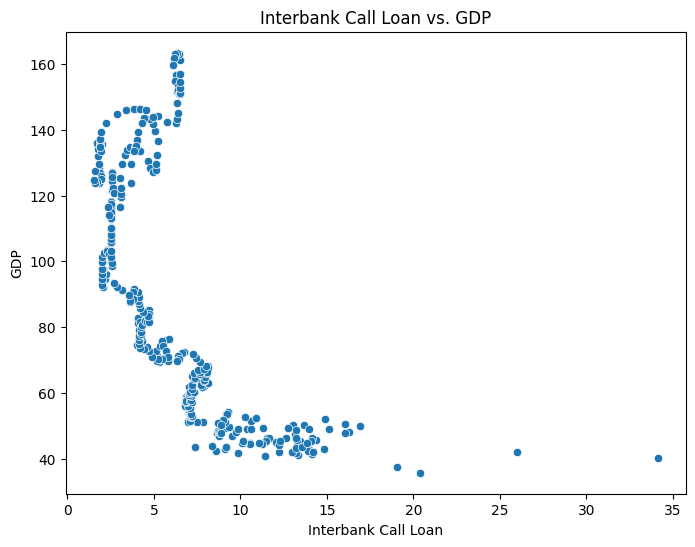

In [ ]:
# Check for correlation between Interbank Call Loan and GDP
correlation_loan_gdp = df_interest_rate[['Interbank Call Loan Rate', 'Real GDP']].corr()
print(correlation_loan_gdp)

# Plot the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_interest_rate, x='Interbank Call Loan Rate', y='Real GDP')
plt.title('Interbank Call Loan vs. GDP')
plt.xlabel('Interbank Call Loan')
plt.ylabel('GDP')
plt.show()

                          Interbank Call Loan Rate       CPI
Interbank Call Loan Rate                  1.000000 -0.720946
CPI                                      -0.720946  1.000000


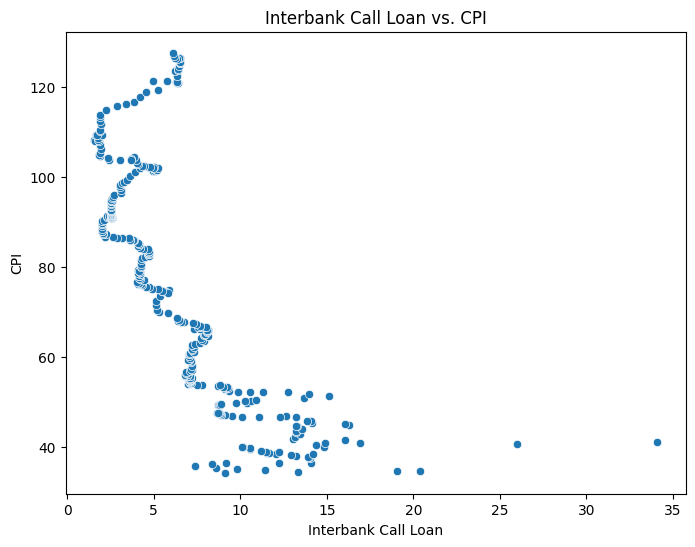

In [ ]:
# Check for correlation between Interbank Call Loan and CPI
correlation_loan_cpi = df_interest_rate[['Interbank Call Loan Rate', 'CPI']].corr()
print(correlation_loan_cpi)

# Plot the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_interest_rate, x='Interbank Call Loan Rate', y='CPI')
plt.title('Interbank Call Loan vs. CPI')
plt.xlabel('Interbank Call Loan')
plt.ylabel('CPI')
plt.show()

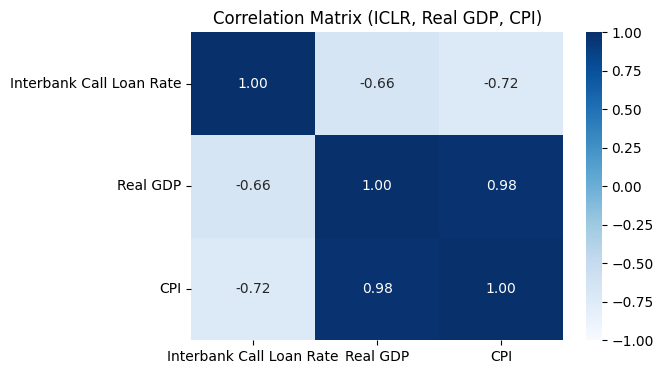

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Correlation matrix for selected variables
corr_matrix = df_interest_rate[['Interbank Call Loan Rate', 'Real GDP', 'CPI']].corr()

plt.figure(figsize=(6, 4))

# Use a blue-only colormap (light to dark blue)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=sns.color_palette("Blues", as_cmap=True),  # blue-only gradient
    vmin=-1, vmax=1,  # ensure consistent scaling
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix (ICLR, Real GDP, CPI)")
plt.show()